In [1]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------------- - 7.9/8.1 MB 57.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 37.2 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -------------- ------------------------- 13.4/37.3 MB 64.9 MB/s eta 0:00:01
   ---------------------------- ----------- 26.7/37.3 MB 63.3 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 60.2 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 45.0 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   -

Total number of points: 130
Cluster 1 (dense):    50 points
Cluster 2 (moderate): 40 points
Cluster 3 (sparse):   30 points
Noise points:         10 points


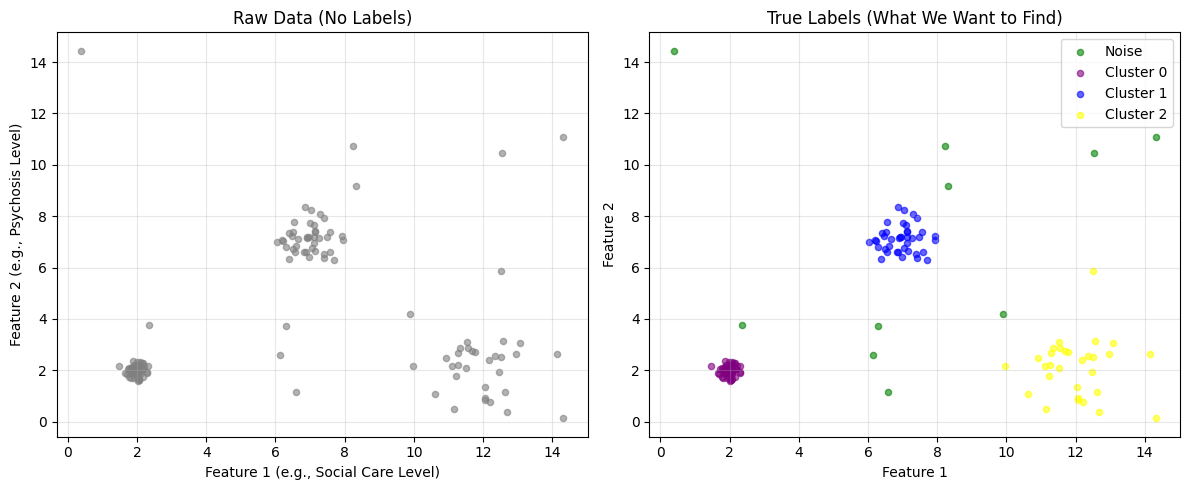

c:\Users\kxk497\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(



--- HDBSCAN Results ---
Number of clusters found: 3
Number of noise points:   5
Cluster labels found:     [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
  Noise (label -1): 5 points
  Cluster 0:      52 points
  Cluster 1:      43 points
  Cluster 2:      30 points


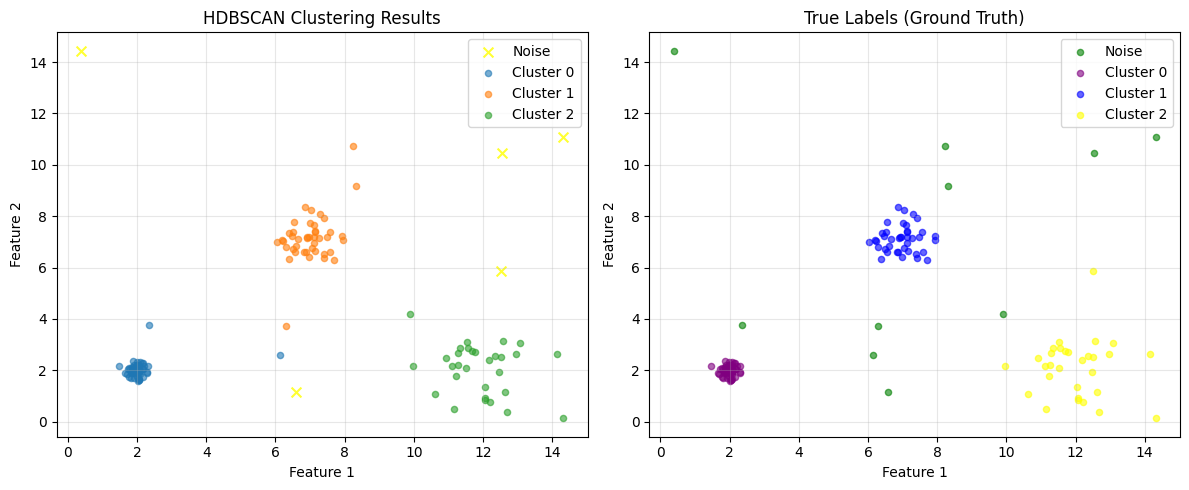

AttributeError: 'HDBSCAN' object has no attribute 'outlier_scores'

In [2]:
# ============================================
# HDBSCAN Clustering - Simple Example
# ============================================

# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
from sklearn.datasets import make_blobs

# ============================================
# Step 2: Create Sample Data
# ============================================
# We'll create three clusters with DIFFERENT densities
# to showcase HDBSCAN's strength

# Cluster 1: Very dense, tight cluster (50 points)
np.random.seed(42)  # For reproducibility
cluster1 = np.random.normal(loc=[2, 2], scale=0.2, size=(50, 2))

# Cluster 2: Moderately dense cluster (40 points)
cluster2 = np.random.normal(loc=[7, 7], scale=0.5, size=(40, 2))

# Cluster 3: Sparse, loose cluster (30 points)
cluster3 = np.random.normal(loc=[12, 2], scale=1.0, size=(30, 2))

# Add some noise/outlier points (10 points)
noise = np.random.uniform(low=0, high=15, size=(10, 2))

# Combine all points into one dataset
X = np.vstack([cluster1, cluster2, cluster3, noise])

# Create labels for visualization (to compare later)
true_labels = np.array(
    [0]*50 + [1]*40 + [2]*30 + [-1]*10
)

print(f"Total number of points: {len(X)}")
print(f"Cluster 1 (dense):    {len(cluster1)} points")
print(f"Cluster 2 (moderate): {len(cluster2)} points")
print(f"Cluster 3 (sparse):   {len(cluster3)} points")
print(f"Noise points:         {len(noise)} points")

# ============================================
# Step 3: Visualize the Raw Data
# ============================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', s=20, alpha=0.6)
plt.title('Raw Data (No Labels)')
plt.xlabel('Feature 1 (e.g., Social Care Level)')
plt.ylabel('Feature 2 (e.g., Psychosis Level)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
colors_true = ['green', 'purple', 'blue', 'yellow']
for label in [-1, 0, 1, 2]:
    mask = true_labels == label
    color = colors_true[label + 1]
    name = f'Cluster {label}' if label >= 0 else 'Noise'
    plt.scatter(X[mask, 0], X[mask, 1], c=color, 
                s=20, alpha=0.6, label=name)
plt.title('True Labels (What We Want to Find)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_raw_data.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Step 4: Apply HDBSCAN
# ============================================
# Key parameters:
#   min_cluster_size: minimum number of points to form a cluster
#                     (this is the parameter 'p' from our discussion)
#   min_samples:      number of points in neighborhood for core distance
#                     (this is the parameter 's' from our discussion)

hdbscan = HDBSCAN(
    min_cluster_size=10,  # Cluster must have at least 10 points
    min_samples=5,        # Use 5 nearest neighbors for core distance
)

# Fit the model and get cluster labels
cluster_labels = hdbscan.fit_predict(X)

# ============================================
# Step 5: Examine the Results
# ============================================
# Cluster labels: -1 means noise/outlier, 0,1,2,... are cluster IDs
unique_labels = set(cluster_labels)
n_clusters = len(unique_labels - {-1})  # Exclude noise label
n_noise = list(cluster_labels).count(-1)

print(f"\n--- HDBSCAN Results ---")
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points:   {n_noise}")
print(f"Cluster labels found:     {sorted(unique_labels)}")

# Count points in each cluster
for label in sorted(unique_labels):
    count = list(cluster_labels).count(label)
    if label == -1:
        print(f"  Noise (label -1): {count} points")
    else:
        print(f"  Cluster {label}:      {count} points")

# ============================================
# Step 6: Visualize HDBSCAN Results
# ============================================
plt.figure(figsize=(12, 5))

# Plot HDBSCAN results
plt.subplot(1, 2, 1)
# Create a colormap for clusters
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for label in sorted(unique_labels):
    mask = cluster_labels == label
    if label == -1:
        # Noise points: plot as yellow X markers
        plt.scatter(X[mask, 0], X[mask, 1], c='yellow', 
                    marker='x', s=50, alpha=0.8, label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], c=[colors[label]], 
                    s=20, alpha=0.6, label=f'Cluster {label}')

plt.title('HDBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot true labels for comparison
plt.subplot(1, 2, 2)
for label in [-1, 0, 1, 2]:
    mask = true_labels == label
    color = colors_true[label + 1]
    name = f'Cluster {label}' if label >= 0 else 'Noise'
    plt.scatter(X[mask, 0], X[mask, 1], c=color, 
                s=20, alpha=0.6, label=name)
plt.title('True Labels (Ground Truth)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_hdbscan_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# Step 7: Access Additional HDBSCAN Information
# ============================================

# --- Outlier Scores (GLOSH) ---
# This is the GLOSH score we discussed
# Values range from 0 (not outlier) to 1 (strong outlier)
outlier_scores = hdbscan.outlier_scores

print(f"\n--- Outlier Scores (GLOSH) ---")
print(f"Min outlier score:  {outlier_scores.min():.4f}")
print(f"Max outlier score:  {outlier_scores.max():.4f}")
print(f"Mean outlier score: {outlier_scores.mean():.4f}")

# Visualize outlier scores
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=outlier_scores, 
                       cmap='RdYlGn_r', s=30, alpha=0.7)
plt.colorbar(scatter, label='GLOSH Outlier Score')
plt.title('GLOSH Outlier Scores\n(Red = Strong Outlier, '
          'Green = Not an Outlier)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.savefig('03_outlier_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Cluster Probabilities ---
# How confident is the algorithm that each point 
# belongs to its assigned cluster?
# 0 = noise, higher = more confident
probabilities = hdbscan.probabilities_

print(f"\n--- Cluster Membership Probabilities ---")
print(f"Min probability:  {probabilities.min():.4f}")
print(f"Max probability:  {probabilities.max():.4f}")
print(f"Mean probability: {probabilities.mean():.4f}")

# Visualize probabilities
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=probabilities, 
                       cmap='viridis', s=30, alpha=0.7)
plt.colorbar(scatter, label='Cluster Membership Probability')
plt.title('Cluster Membership Probabilities\n'
          '(Bright = High Confidence, '
          'Dark = Low Confidence/Noise)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.savefig('04_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()